# Práctica APA 
##### Sambhav Mayani y Esteve Estop
#### Descripción del conjunto de datos y su fuente
Este dataset es el resultado de un estudio de "viñetas" donde se preguntó a participantes qué salario consideraban "justo" (just) para una serie de perfiles de trabajadores ficticios. Contiene 38.183 juicios de salario y 20 variables. El objetivo es un problema de regresión: predecir el salario justo basándose en las características del perfil ficticio, como su ocupación (v_occ), su género (v_gender), su edad (v_age), sus años de experiencia (v_jobexp) y si tenía hijos (v_child).´

Este es el link: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/CKJI71 



In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Carga de los datos
df = pd.read_csv('vignette-study-1-just-earnings.tab', sep='\t')

df.head()

,respid,vignid,r_gender,just,lnjust,v_psco,v_occ,v_isco,v_isco3,v_prscale,v_prcat,v_high,prop_fem,v_segr,v_gender,v_age,v_agebin,v_child,v_childcat,v_jobexp
0,346.0,103.0,2,4662.147020,8.447231,3116,Librarian,2622.0,262.0,61.3,2,0.0,0.709924,3,2,60.0,1.0,0.0,1,32.0
1,346.0,866.0,2,4196.258792,8.341949,6413,Cloakroom attendant,9629.0,962.0,8.6,1,0.0,0.486547,2,2,55.0,1.0,1.0,2,29.0
2,346.0,249.0,2,5305.565690,8.576512,1114,Artistic director in an advertising agency,1222.0,122.0,72.7,3,1.0,0.425197,2,1,30.0,0.0,0.0,1,3.0
3,346.0,205.0,2,4445.766186,8.399708,6411,Janitor,5153.0,515.0,10.4,1,0.0,0.397321,2,1,50.0,1.0,1.0,2,25.0
4,346.0,788.0,2,6111.453857,8.717920,1238,IT security specialist,2522.0,252.0,77.5,3,1.0,0.168293,1,1,65.0,1.0,1.0,2,36.0


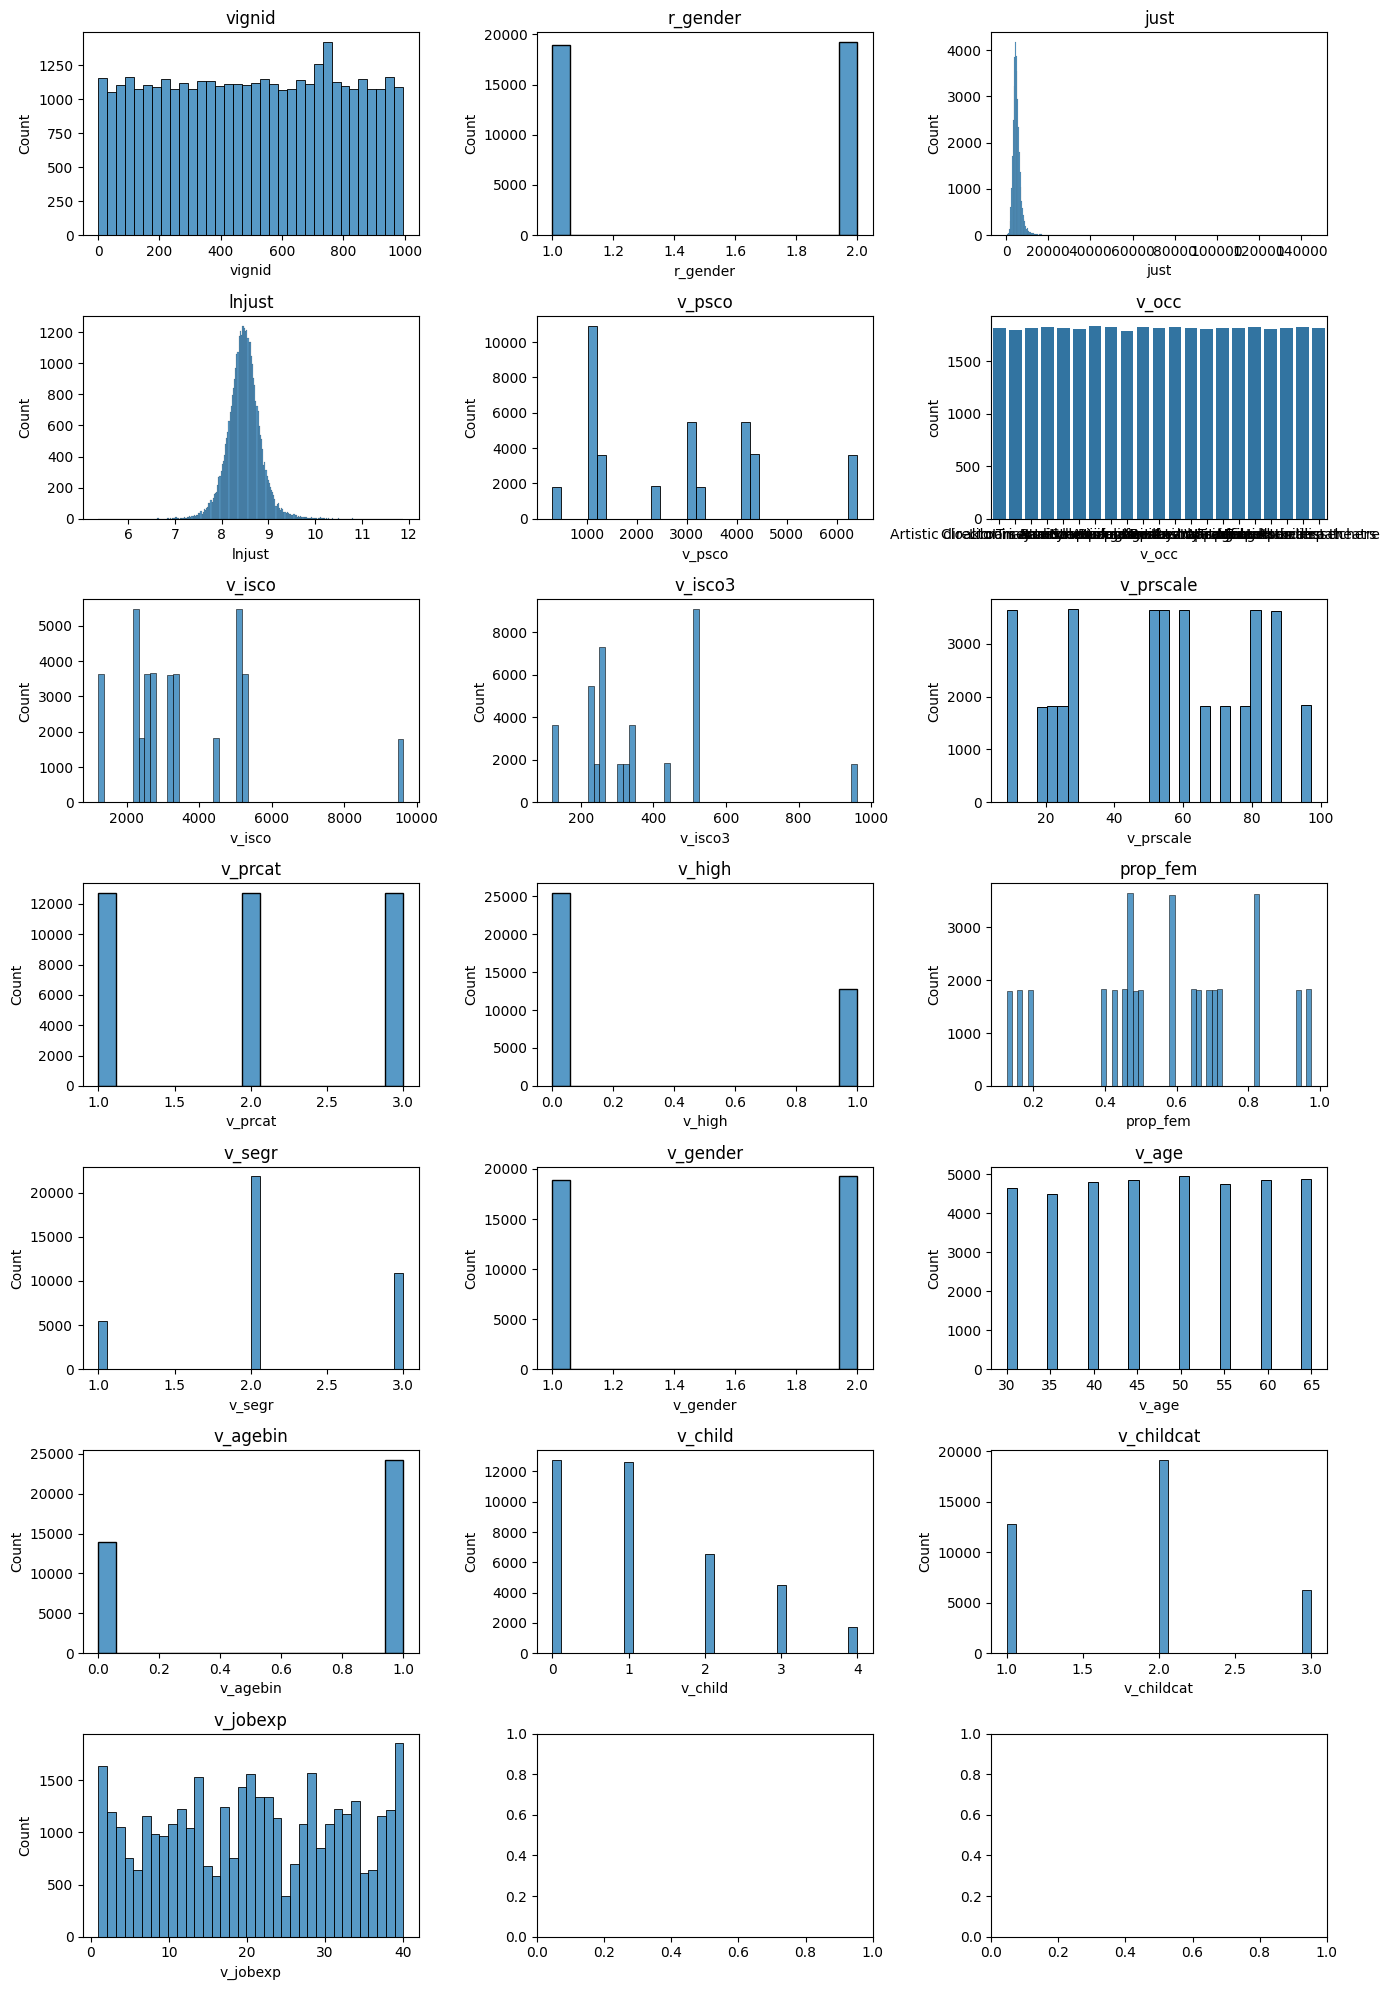

In [48]:
# Visualización simple
fig, axes = plt.subplots(7,3,figsize=(14,20))

for i, c in enumerate(df.columns[1:]):
    ax = axes.reshape(-1)[i]
    if df[c].dtype.kind == 'O':
        sns.countplot(x=c,data=df,ax=ax)
    else:
        sns.histplot(x=c,data=df,ax=ax)
    ax.set_title(c)
plt.tight_layout()

In [49]:
# Missing values
print('Missing Values\n')

for var in df.columns:
    missing = df[var].isna().sum()
    print(str(var) + ': ' + str(missing))

Missing Values

respid: 0
vignid: 0
r_gender: 0
just: 0
lnjust: 0
v_psco: 0
v_occ: 0
v_isco: 0
v_isco3: 0
v_prscale: 0
v_prcat: 0
v_high: 0
prop_fem: 0
v_segr: 0
v_gender: 0
v_age: 0
v_agebin: 0
v_child: 0
v_childcat: 0
v_jobexp: 0


In [50]:
# Valores incoherentes

# Revisión rangos de edad
print(f"Rango de edad: {df['v_age'].min()} a {df['v_age'].max()} años.")

# Revisión experiencia
print(f"Rango de experiencia: {df['v_jobexp'].min()} a {df['v_jobexp'].max()} años.")

# Revisión (Edad - Experiencia) > 14 años
casos_imposibles = df[df['v_jobexp'] > (df['v_age'] - 14)]

print(f"Experiencia > (Edad - 14): {len(casos_imposibles)}")

Rango de edad: 30.0 a 65.0 años.
Rango de experiencia: 1.0 a 40.0 años.
Experiencia > (Edad - 14): 0


In [51]:
# Borrado de identificadores que no aportan info útil para la predicción
df_clean = df.drop(columns=['respid', 'vignid'])

# Partición conjunto de datos 80 20
X = df_clean.drop(columns=['just', 'lnjust'])
y = df_clean['just']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

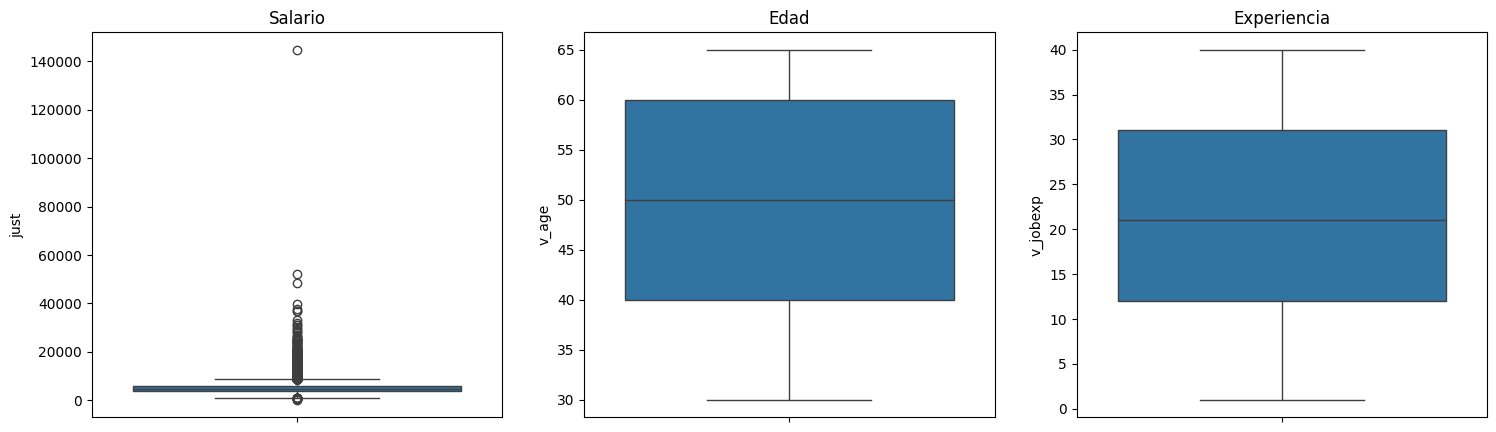

In [52]:
# Outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salario
sns.boxplot(y=y_train, ax=axes[0])
axes[0].set_title('Salario')

# Edad
sns.boxplot(y=X_train['v_age'], ax=axes[1])
axes[1].set_title('Edad')

# Experiencia
sns.boxplot(y=X_train['v_jobexp'], ax=axes[2])
axes[2].set_title('Experiencia')

plt.show()

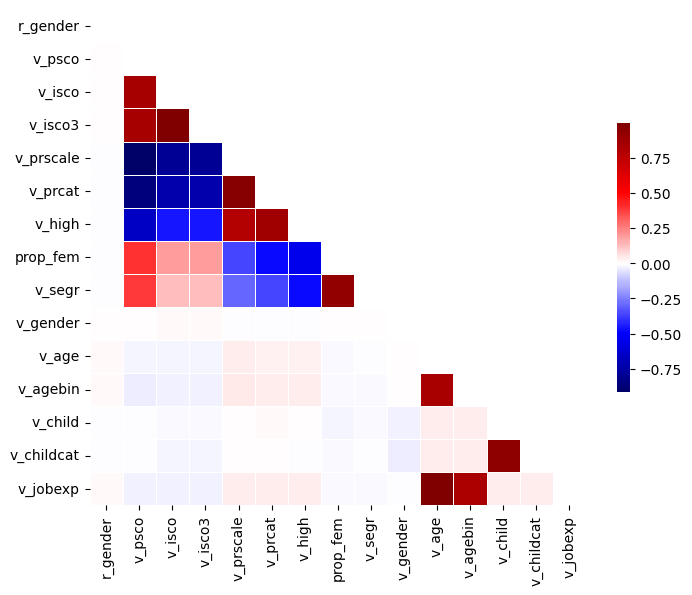

In [53]:
# Matriz de correlación de las variables
import numpy as np
corr = X_train.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.subplots(figsize=(8, 7))
sns.heatmap(corr, mask=mask, cmap='seismic',  center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5});

In [54]:
# Variables redundantes
numeric_X_train = X_train.select_dtypes(include=[np.number])

corr_matrix = numeric_X_train.corr()

print("Alta correlación")
# Recorremos la matriz
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.90:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            score = corr_matrix.iloc[i, j]
            print(f"{colname_i} y {colname_j}: {score:.4f}")

Alta correlación
v_isco3 y v_isco: 1.0000
v_prscale y v_psco: -0.9145
v_prcat y v_prscale: 0.9633
v_segr y prop_fem: 0.9169
v_childcat y v_child: 0.9365
v_jobexp y v_age: 0.9941


In [55]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Selección de características
cols_to_drop = [
    'v_isco3',     # Redundante con v_isco
    'v_age',       #    〃 con v_jobexp 
    'v_childcat',  #    〃 con v_child 
    'v_segr',      #    〃 con prop_fem
    'v_prscale',   #    〃 con v_psco 
    'v_prcat'      #    〃 con v_psco
]

X_train = X_train.drop(columns=cols_to_drop) 
X_test = X_test.drop(columns=cols_to_drop)

col_ocupacion = 'v_occ' 
categorical_features = [col_ocupacion]
numeric_features = [col for col in X_train.columns if col not in categorical_features and pd.api.types.is_numeric_dtype(X[col])]

print(f"Variables eliminadas: {cols_to_drop}")

# Escalado variables numéricas
scaler = StandardScaler()

# fit aprende solo del conjunto de entrenamiento
X_train_num_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_num_scaled = scaler.transform(X_test[numeric_features])

# Codificación variables categóricas
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_cat_encoded = encoder.transform(X_test[categorical_features])

# Unimos
X_train_proc = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_test_proc = np.hstack([X_test_num_scaled, X_test_cat_encoded])


Variables eliminadas: ['v_isco3', 'v_age', 'v_childcat', 'v_segr', 'v_prscale', 'v_prcat']


Varianza por componente: [0.28834098 0.20321483 0.11465475 0.11103752 0.10746577 0.10279435
 0.04157311 0.01837362 0.01254508]
Varianza acumulada: [0.28834098 0.49155581 0.60621056 0.71724808 0.82471385 0.92750819
 0.96908131 0.98745492 1.        ]


Text(0.5, 1.0, 'Heatmap')

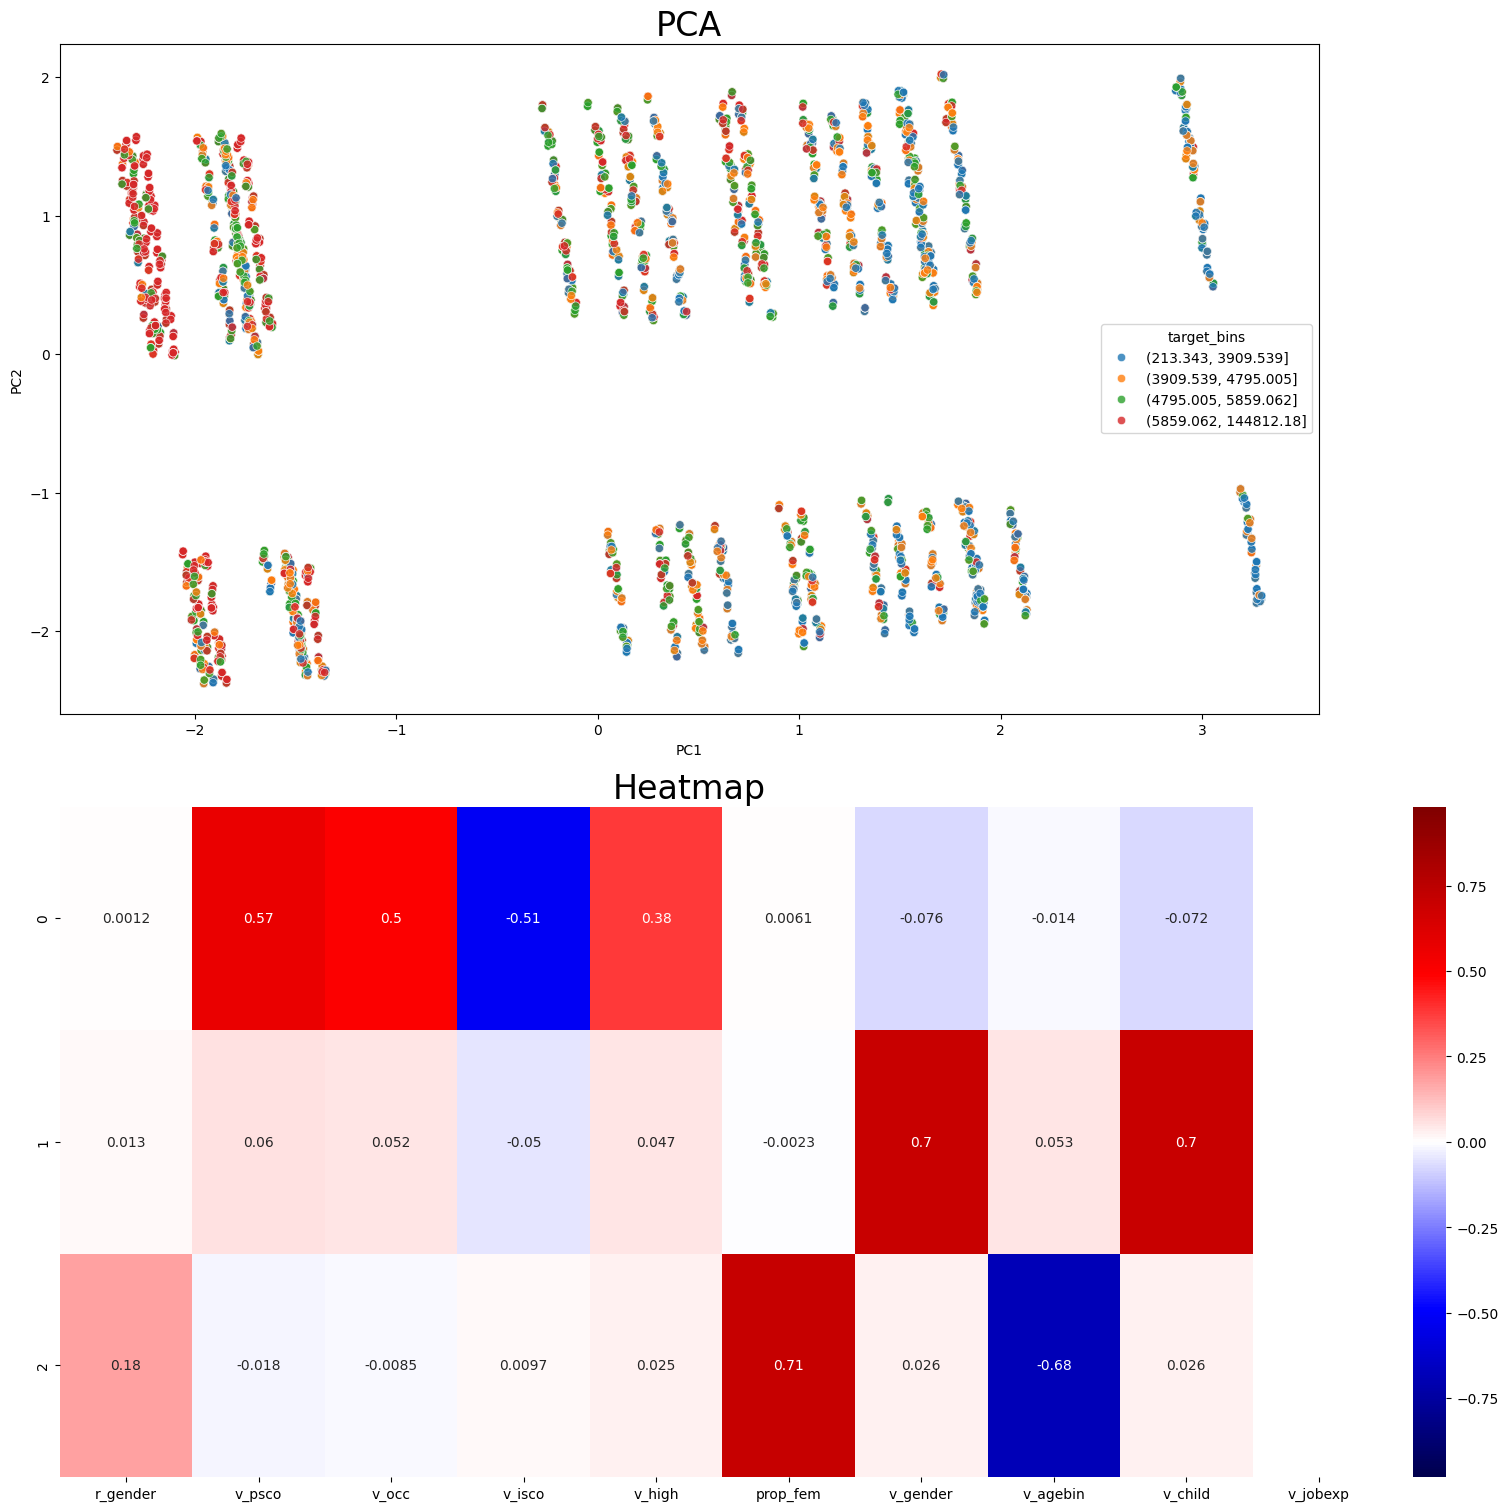

In [62]:
myPCA = PCA()
X_pca = myPCA.fit_transform(X_train_num_scaled)

print("Varianza por componente:", myPCA.explained_variance_ratio_)
print("Varianza acumulada:", myPCA.explained_variance_ratio_.cumsum())


df_visual = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'target': y_train
})

df_visual['target_bins'] = pd.qcut(df_visual['target'], q=4) # para ver los rangos pintados en el PCA y se vea mejor


fig, axes= plt.subplots(2,1, figsize=(15,15), constrained_layout= True)

sns.scatterplot(x='PC1', y='PC2', hue='target_bins', data=df_visual, alpha=0.8, ax=axes[0])
axes[0].set_title("PCA", fontsize=24)


sns.heatmap(myPCA.components_[:3], cmap='seismic', 
            xticklabels=list(X_train.columns),
            vmin=-np.max(np.abs(myPCA.components_)),
            vmax=np.max(np.abs(myPCA.components_)),
            annot=True, ax= axes[1])
axes[1].set_title("Heatmap", fontsize=24)

<Axes: xlabel='PC1', ylabel='PC2'>

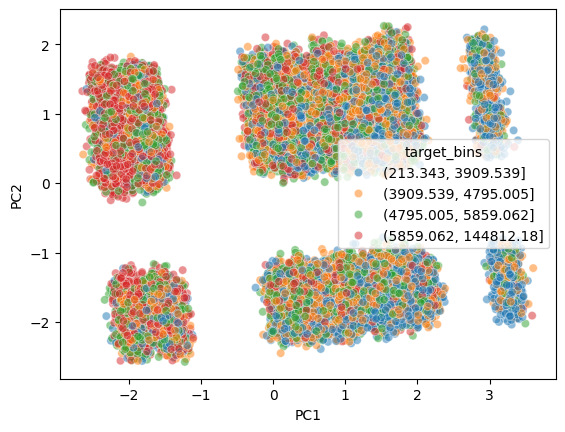

In [70]:
sns.scatterplot(
    x = df_visual['PC1'] + np.random.normal(0, 0.1, len(df_visual)), # añadimos un poco de dispersión artifial para ver mejor los datos
    y = df_visual['PC2'] + np.random.normal(0, 0.1, len(df_visual)),
    alpha=0.5, 
    hue='target_bins', 
    data=df_visual
)

In [ ]:
import plotly.express as px

fig = px.scatter_3d(df_visual, x='PC1', y='PC2', z='PC3', color='target_bins')
fig.update_traces(marker=dict(size=3)) # hacemos los puntos más pequeños para que se vean mejor
fig.show()



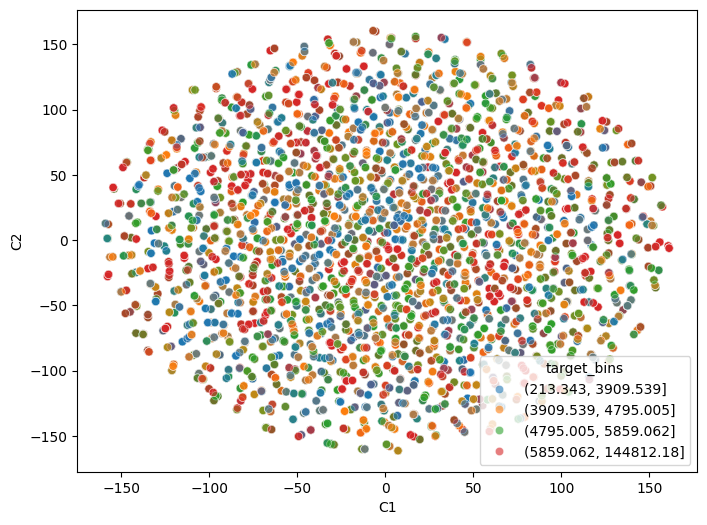

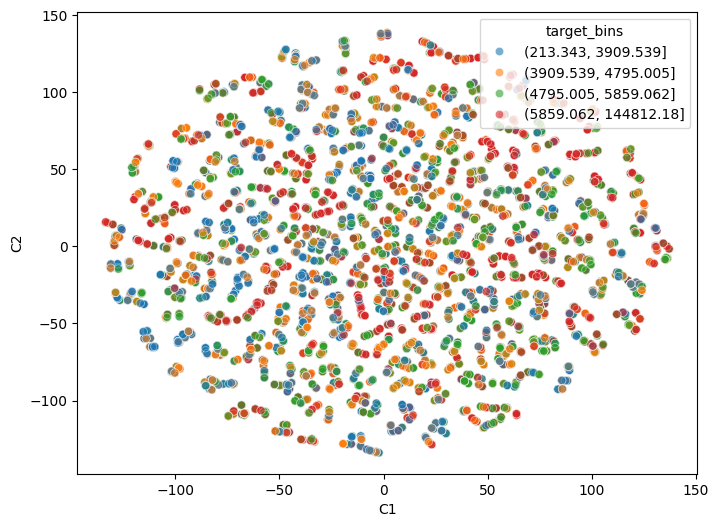

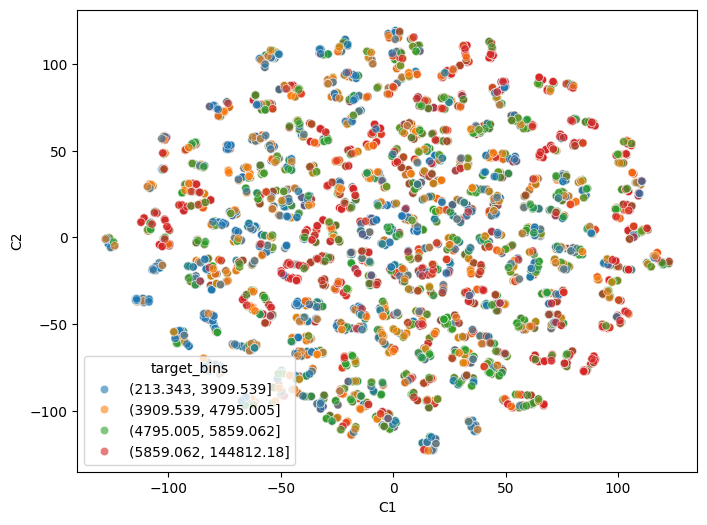

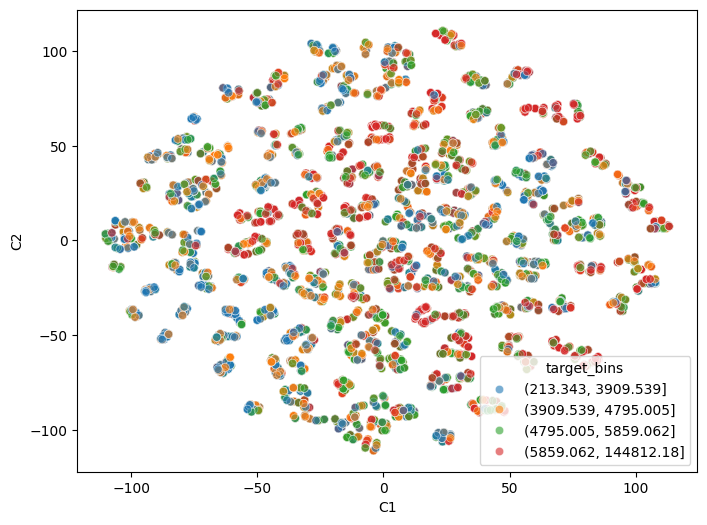

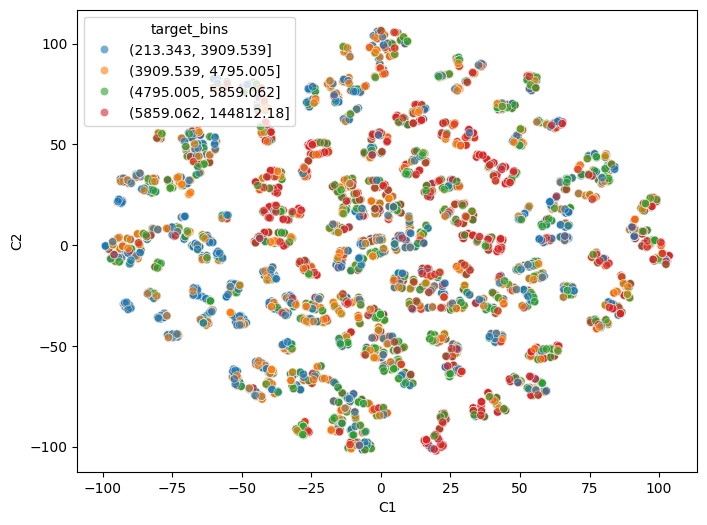

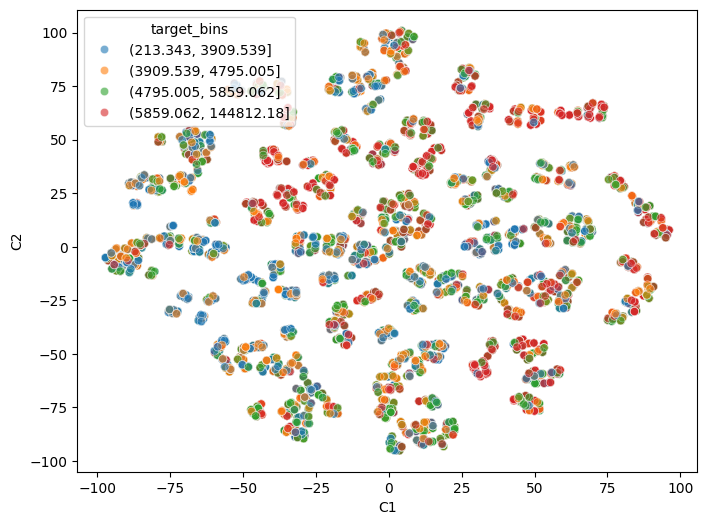

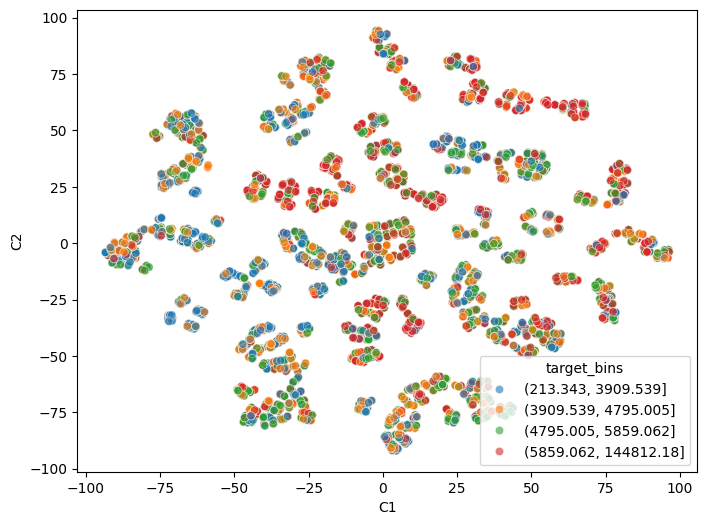

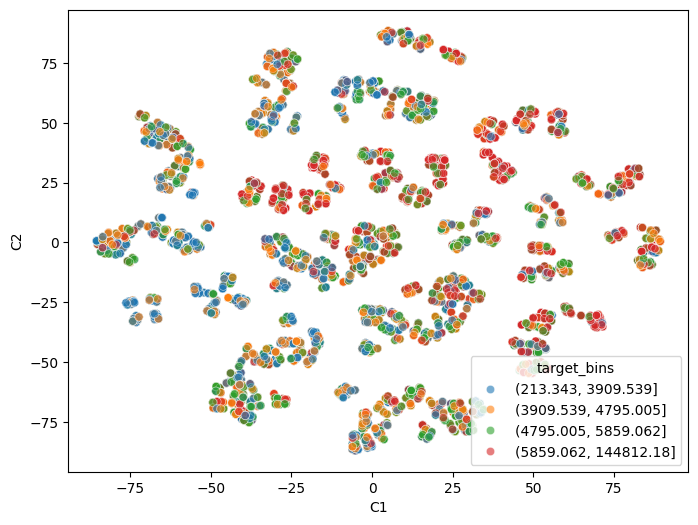

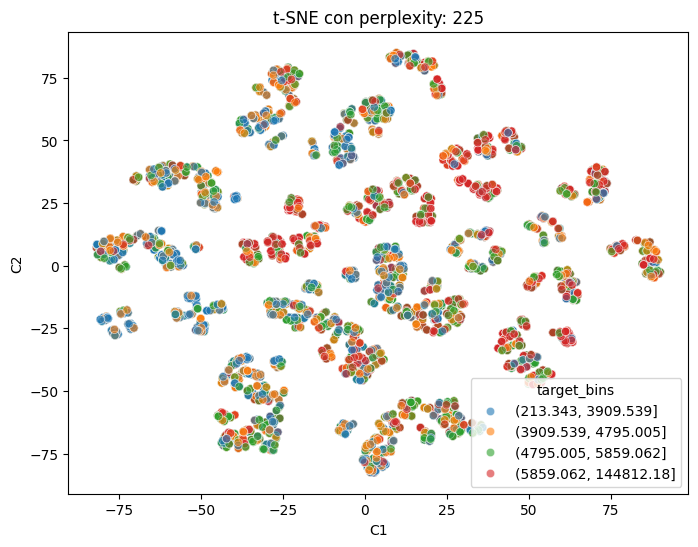

In [82]:

for i in range(1,10): # como que tarda bastante dejo un for para que vaya haciendo
    tsne = TSNE( n_components=2, perplexity=25*i, init='random', learning_rate='auto', random_state= 77) # el perplexity lo he ido ajustando manualmente, hasta quedarme con uno
                                                                                                    # que no divida demasiado ni demasiado poco.

    X_tsne = tsne.fit_transform(X_train_num_scaled)

    df_visual_tsne = pd.DataFrame({
        'C1': X_tsne[:, 0],
        'C2': X_tsne[:, 1],
        'target': y_train
    })

    df_visual_tsne['target_bins'] = pd.qcut(df_visual['target'], q=4) # para ver los rangos pintados en el PCA y se vea mejor

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='C1', y='C2', hue='target_bins', alpha=0.6, data=df_visual_tsne)
plt.title(f"t-SNE con perplexity: {25*i}")
plt.show()



Comparativa de modelos

Modelo: Regresión Lineal
   R²: 0.2379
   MAE: 1134.32 €

Modelo: Ridge
   R²: 0.2379
   MAE: 1134.31 €

Modelo: Lasso
   R²: 0.2379
   MAE: 1134.26 €

Gráficos modelo Lasso


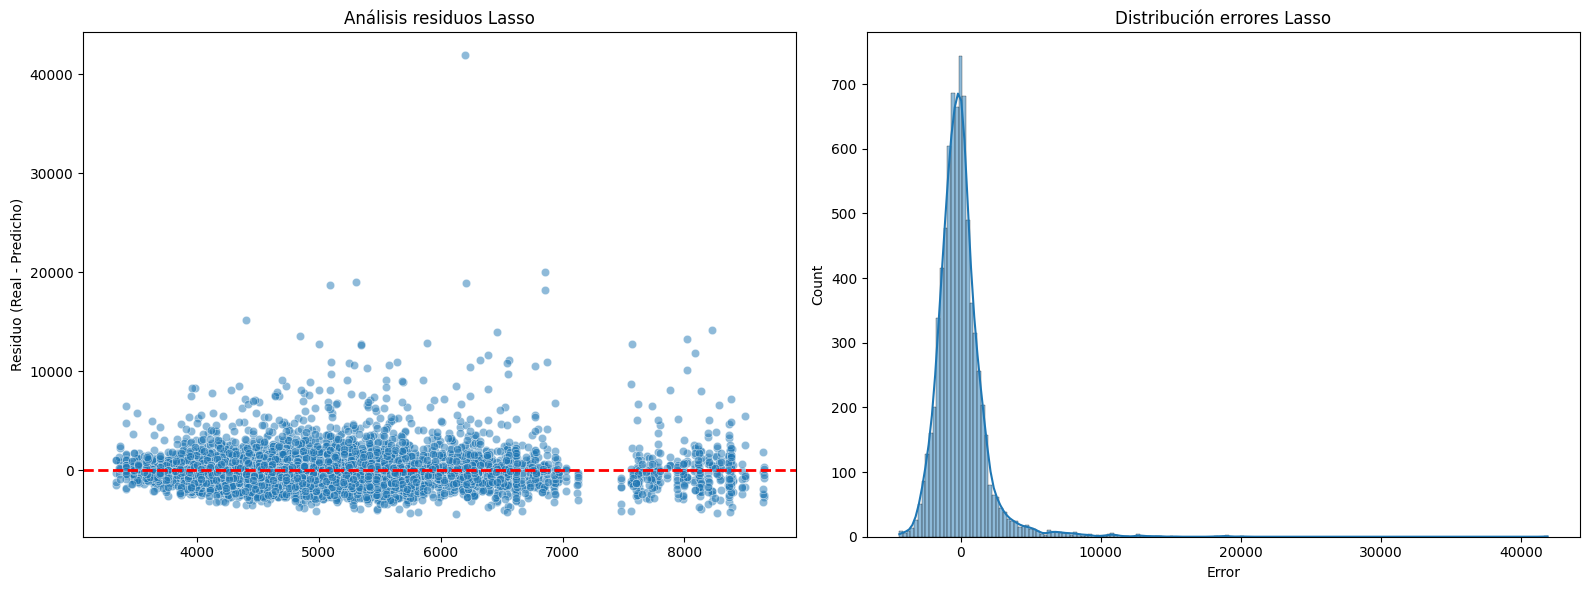

In [ ]:


# Entrenamiento 3 modelos
modelos = [
    ('Regresión Lineal', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0)),
    ('Lasso', Lasso(alpha=0.1, max_iter=20000))
]

print("\nComparativa de modelos")

y_pred_loop = None

for nombre, modelo in modelos:
    modelo.fit(X_train_proc, y_train)
    
    prediccion = modelo.predict(X_test_proc)
    
    y_pred_loop = prediccion
    
    r2 = r2_score(y_test, prediccion)
    mae = mean_absolute_error(y_test, prediccion)
    
    print(f"\nModelo: {nombre}")
    print(f"   R²: {r2:.4f}")
    print(f"   MAE: {mae:.2f} €")


# Gráficos del último modelo (Lasso)

r2_final = r2_score(y_test, y_pred_loop)
mae_final = mean_absolute_error(y_test, y_pred_loop)

print(f"\nGráficos modelo Lasso")

residuals = y_test - y_pred_loop

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y_pred_loop, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Análisis residuos Lasso')
axes[0].set_xlabel('Salario Predicho')
axes[0].set_ylabel('Residuo (Real - Predicho)')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Distribución errores Lasso')
axes[1].set_xlabel('Error')

plt.tight_layout()
plt.show()

In [83]:
def evaluar_regresion_visual(model, X_test, y_test, nombre_modelo, feature_names=None): # para modelos lineales
    y_pred = model.predict(X_test)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico real vs predicho
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=axes[0])
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea ideal
    axes[0].set_title(f'{nombre_modelo}: Real vs Predicho')
    axes[0].set_xlabel('Salario Real')
    axes[0].set_ylabel('Salario Predicho')
    
    # Importancia de las variables
    if hasattr(model, 'coef_') or hasattr(model, 'named_steps'):
        # Extraer coeficientes si es un pipeline o modelo directo
        # if hasattr(model, 'named_steps'):
        #     # Caso Pipeline: extraemos del paso final (regresor) y nombres del preprocesador
        #     coeffs = model.named_steps['regressor'].coef_
        #     # Obtener nombres de features tras OneHotEncoding es complejo, usaremos índices si falla
        #     try:
        #         feat_names = model.named_steps['preprocessor'].get_feature_names_out()
        #     except:
        #         feat_names = [f'Feat {i}' for i in range(len(coeffs))]
        # else:
        coeffs = model.coef_
        feat_names = feature_names if feature_names is not None else [f'F{i}' for i in range(len(coeffs))]
            
        # Creamos DataFrame para ordenar
        df_coeffs = pd.DataFrame({'Feature': feat_names, 'Coef': coeffs})
        df_coeffs['Abs_Coef'] = df_coeffs['Coef'].abs()
        top_features = df_coeffs.sort_values(by='Abs_Coef', ascending=False).head(15) # Top 15
        
        sns.barplot(data=top_features, x='Coef', y='Feature', ax=axes[1], palette='coolwarm')
        axes[1].set_title(f'{nombre_modelo}: Top 15 Atributos más influyentes')
    
    plt.tight_layout()
    plt.show()


Entrenando MLP (Redes Neuronales)...
Modelo: MLP (Redes Neuronales)
   Mejor R²: 0.2402
   MAE: 1130.94 €
   Mejores Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': 300, 'learning_rate': 'invscaling', 'learning_rate_init': 0.001, 'n_iter_no_change': 30}


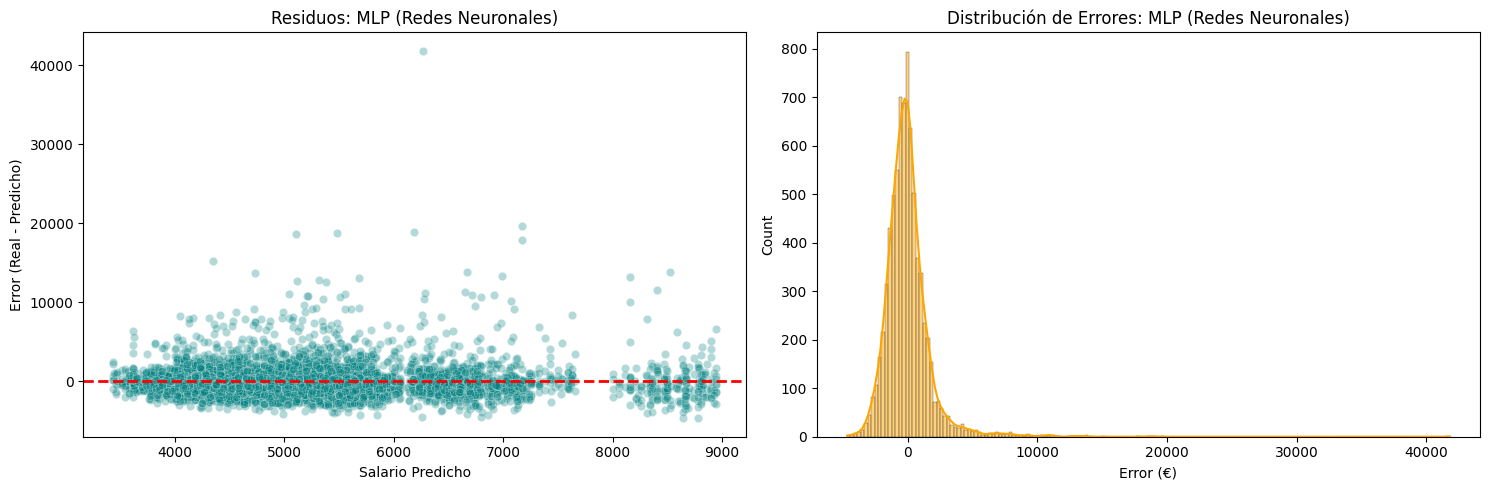


Entrenando Random Forest...
Modelo: Random Forest
   Mejor R²: 0.2300
   MAE: 1139.44 €
   Mejores Params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 25}


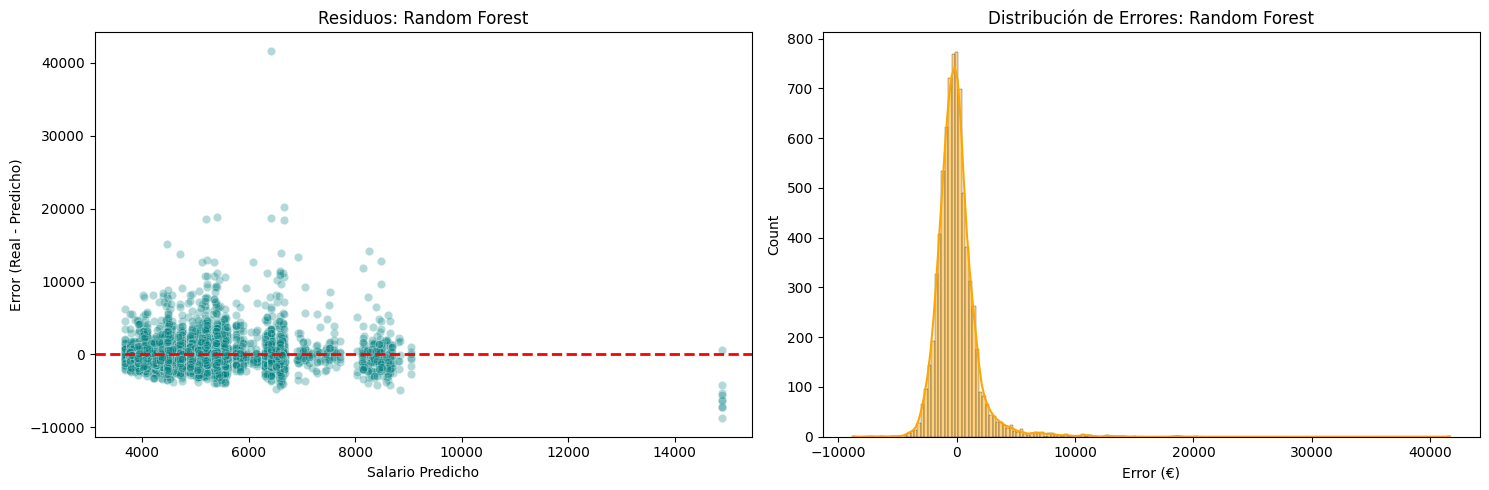


Entrenando SVM (RBF)...
Modelo: SVM (RBF)
   Mejor R²: 0.1186
   MAE: 1212.52 €
   Mejores Params: {'C': 1.513561248436207, 'epsilon': 0.007}


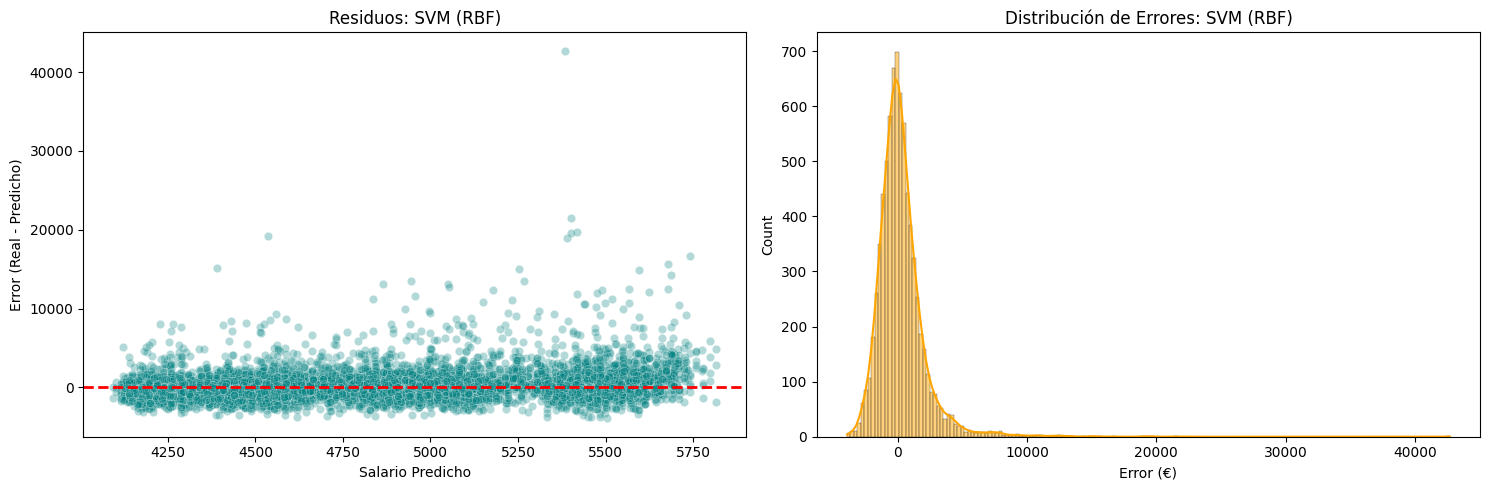

C:\Users\sambh\AppData\Local\Temp\ipykernel_22576\1300307654.py:103: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




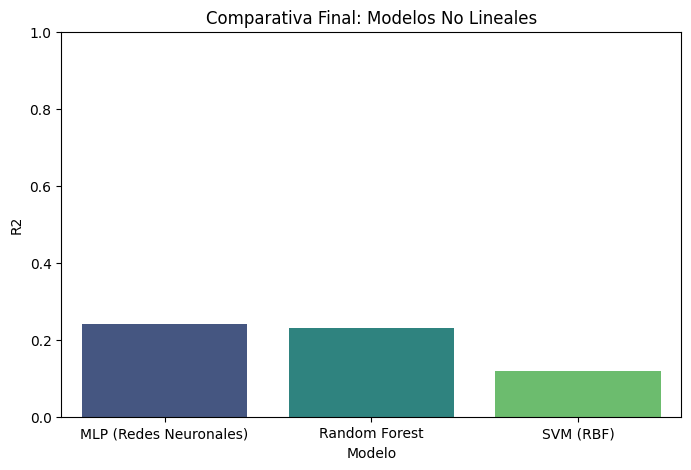

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.utils import resample

# Reducimos los datos de entrenamiento SOLO para la búsqueda de hiperparámetros,
# unas 4000 muestras son suficientes para encontrar buenos hiperparámetros estadísticamente.
# Ya he intentado ejecutar el modelo entero con pocas iteraciones pero los resultados no son muy buenos
X_train_sample, y_train_sample = resample(X_train_proc, y_train, n_samples=4000, random_state=42)

niter = 5
cv = 3

param_mlp = {'hidden_layer_sizes':[50, 100, 200], 
         'activation':['relu',  'logistic'], 
         'alpha':[0.0001, 0.001, 0.01],
         'learning_rate_init': [0.001, 0.01, 0.1],
         'n_iter_no_change':[30, 40, 50], 
         'learning_rate': ['constant', 'invscaling', 'adaptive']}

mlp =  MLPRegressor(max_iter=5000,early_stopping=True,random_state=0)
opt_mlp = BayesSearchCV(mlp,param_mlp, 
                        cv=cv, 
                        n_jobs=-1, 
                        refit=True, random_state=0,
                        n_iter= niter)  

param_rf = {'n_estimators': [5,10,25,40, 50, 75,100, 200], 
         'max_depth':[None, 1, 2, 3,  5,  8, 9,10,15],
         'min_samples_leaf':[1,2,3,5,10]}

rf = RandomForestRegressor(random_state=0, n_jobs=-1)
opt_rf = BayesSearchCV(rf , param_rf, 
                       cv=cv, 
                       n_jobs=-1, 
                       random_state=0, 
                       verbose=0,
                       n_iter= niter
)

param_svm = {'C':10**np.linspace(-3,3,101), 'epsilon':np.linspace(0,0.01,11)}

lsvr =  SVR(kernel='rbf', max_iter=25000, cache_size=2000)
opt_svm = BayesSearchCV(lsvr,param_svm, 
                        cv=cv, 
                        n_jobs=-1, 
                        random_state=0,
                        n_iter = niter)

modelos_no_lineales = [
    ('MLP (Redes Neuronales)', opt_mlp),
    ('Random Forest', opt_rf),
    ('SVM (RBF)', opt_svm)
]


resultados = []

for nombre, modelo in modelos_no_lineales:
    print(f"\nEntrenando {nombre}...")
    
    modelo.fit(X_train_proc, y_train)
    
    prediccion = modelo.predict(X_test_proc)
    ultimo_modelo_pred = prediccion
    
    r2 = r2_score(y_test, prediccion)
    mae = mean_absolute_error(y_test, prediccion)
    
    resultados.append({'Modelo': nombre, 'R2': r2, 'MAE': mae, 'Params': modelo.best_params_})
    
    print(f"Modelo: {nombre}")
    print(f"   Mejor R²: {r2:.4f}")
    print(f"   MAE: {mae:.2f} €")
    print(f"   Mejores Params: {dict(modelo.best_params_)}")

    residuals = y_test - prediccion
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Predicho vs Residuos
    sns.scatterplot(x=prediccion, y=residuals, alpha=0.3, ax=axes[0], color='teal')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'Residuos: {nombre}')
    axes[0].set_xlabel('Salario Predicho')
    axes[0].set_ylabel('Error (Real - Predicho)')
    
    # Distribución de errores
    sns.histplot(residuals, kde=True, ax=axes[1], color='orange')
    axes[1].set_title(f'Distribución de Errores: {nombre}')
    axes[1].set_xlabel('Error (€)')
    
    plt.tight_layout()
    plt.show()


df_res = pd.DataFrame(resultados)
plt.figure(figsize=(8, 5))
sns.barplot(data=df_res, x='Modelo', y='R2', palette='viridis')
plt.title('Comparativa Final: Modelos No Lineales')
plt.ylim(0, 1)
plt.show()